In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from collections import Counter, defaultdict

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [8]:
# Load the merged annotations
with open('CS2 Dataset/Merger/merged_input.json', 'r') as f:
    merged_data = json.load(f)

def parse_label_studio_json(data):
    # Parse Label Studio JSON into a flat structure
    
    records = []
    
    for task in data:
        if not task['annotations']:
            continue
            
        # Get the annotation (should be only one per task)
        annotation = task['annotations'][0]
        image_path = task['data']['image']
        
        # Group results by their ID (same bbox, different attributes)
        bbox_groups = defaultdict(dict)
        
        for result in annotation['result']:
            result_id = result['id']
            from_name = result['from_name']
                        
            # Store the attribute value
            if from_name == 'sign_type' and 'rectanglelabels' in result['value']:
                bbox_groups[result_id]['sign_type'] = result['value']['rectanglelabels'][0]
            elif 'choices' in result['value']:
                bbox_groups[result_id][from_name] = result['value']['choices'][0]
        
        # Create a record for each detected sign in the image
        for bbox_id, bbox_data in bbox_groups.items():
            record = {
                'image_path': image_path,
                'file_name': task['file_upload'],
                **bbox_data
            }
            records.append(record)
    
    return pd.DataFrame(records)

# Parse the data
df = parse_label_studio_json(merged_data)
print(f"\nTotal annotated signs: {len(df)}")
df.head()


Total annotated signs: 770


,image_path,file_name,sign_type,view_angle,mounting,condition,sign_shape
0,/data/upload/1/5a8d1ddf-01.back.jpg,5a8d1ddf-01.back.jpg,No Entry (One Way),Back,Pole-mounted,Weathered,Circular
1,/data/upload/1/02ddfe2f-01.front.jpg,02ddfe2f-01.front.jpg,No Entry (One Way),Front,Pole-mounted,Weathered,Circular
2,/data/upload/1/3c028b66-01.side.jpg,3c028b66-01.side.jpg,No Entry (One Way),Side,Pole-mounted,Weathered,Circular
3,/data/upload/1/b4bb6a7b-02.back.jpg,b4bb6a7b-02.back.jpg,Pedestrian Crossing,Back,Pole-mounted,Good,Triangular
4,/data/upload/1/8744159a-02.front.jpg,8744159a-02.front.jpg,Pedestrian Crossing,Front,Pole-mounted,Good,Triangular


In [13]:
# Create a mapping of file_name to member by checking individual files
file_to_member = {}

for json_file in Path('CS2 Dataset/Merger/Individuals').glob('input_*.json'):
    member_name = json_file.stem.replace('input_', '')
    
    with open(json_file, 'r') as f:
        member_data = json.load(f)
    
    # Extract all file names from this member's data
    for task in member_data:
        file_name = task['file_upload']
        file_to_member[file_name] = member_name

# Add member column to dataframe
df['member'] = df['file_name'].map(file_to_member)

In [14]:
print("Dataset Overview:")

member_stats = df.groupby('member').agg({
    'file_name': ['nunique', 'count']
}).droplevel(0, axis=1).rename(columns={'nunique': 'Images', 'count': 'Annotations'})

for member in member_stats.index:
    name = member.replace('_', ' ')
    images = member_stats.loc[member, 'Images']
    annotations = member_stats.loc[member, 'Annotations']
    print(f"{name:20s}{images:3d} images, {annotations:3d} annotations")

print(f"\n{'Total':20s}{member_stats['Images'].sum():3d} images, {member_stats['Annotations'].sum():3d} annotations")
print(f"\nAverage Annotations per Image: {len(df) / df['file_name'].nunique():.2f}")

Dataset Overview:
Daniel Borg Finn    151 images, 154 annotations
Daniela Curmi       165 images, 243 annotations
Matthew Pirotta     164 images, 204 annotations
Matthew Vella       150 images, 169 annotations

Total               630 images, 770 annotations

Average Annotations per Image: 1.22


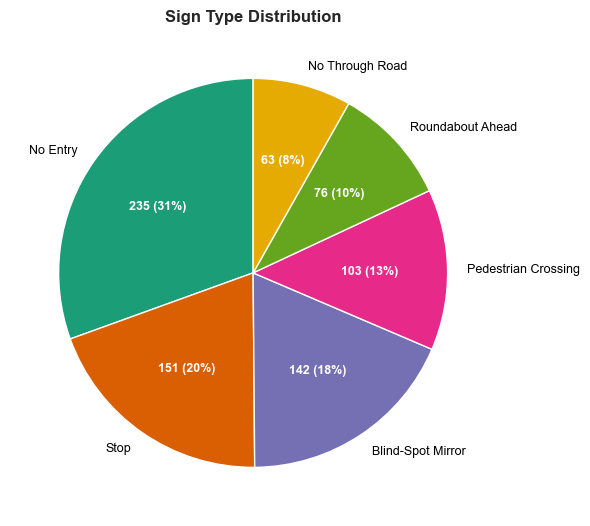

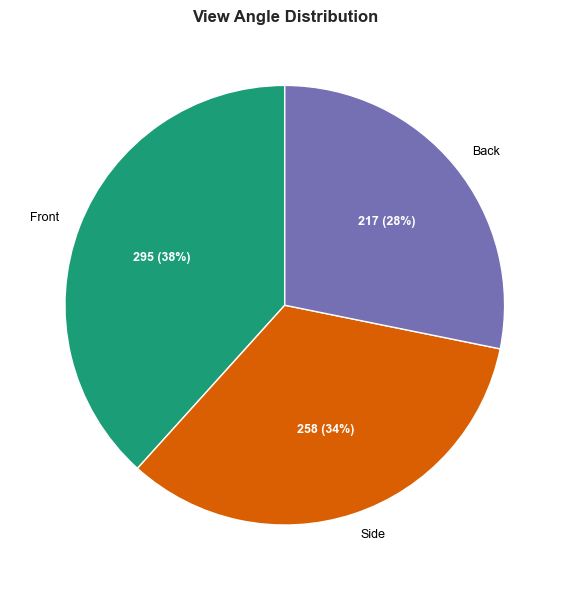

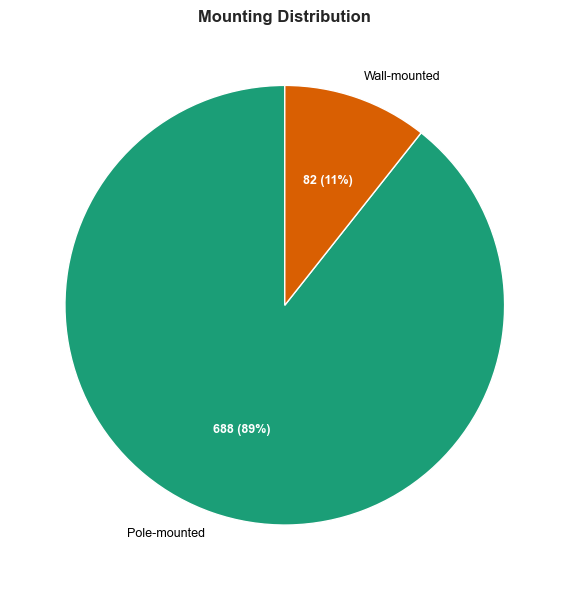

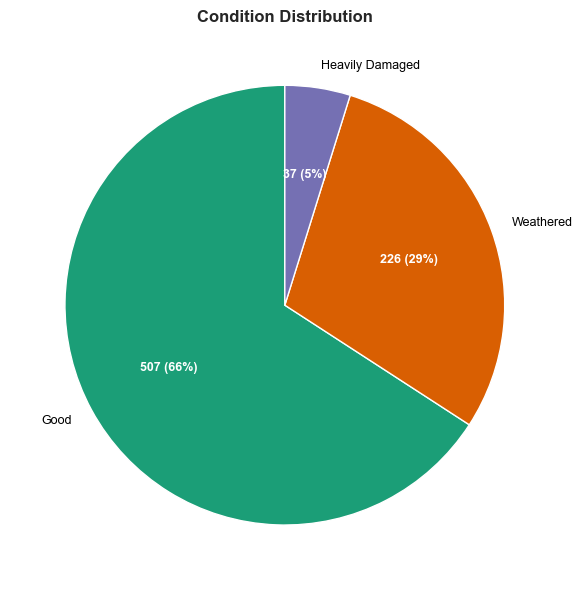

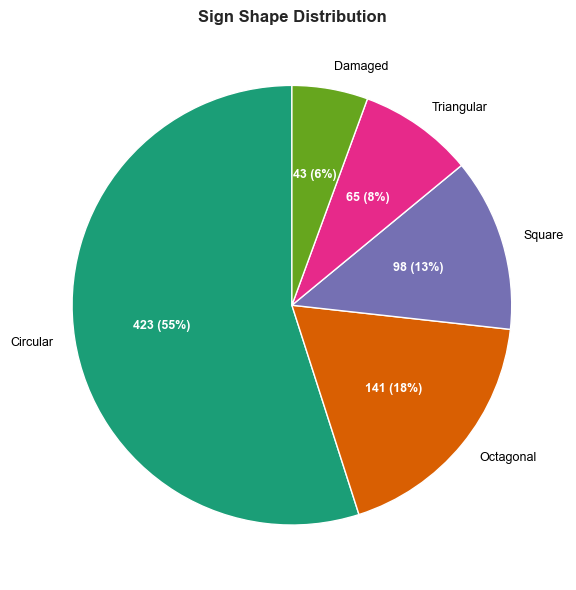

In [15]:
attributes = ['sign_type', 'view_angle', 'mounting', 'condition', 'sign_shape']

for attr in attributes:
    fig, ax = plt.subplots(figsize=(6, 6))
    
    counts = df[attr].value_counts()
    total = counts.sum()

    # Trim labels for sign_type
    if attr == 'sign_type':
        labels = [label.split('(')[0].strip() for label in counts.index]
    else:
        labels = counts.index
    
    cmap = plt.cm.Dark2
    colors = cmap(range(len(counts)))

    def autopct_func(pct):
        count = int(round(pct * total / 100.0))
        return f'{count} ({pct:.0f}%)'

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=labels,
        autopct=autopct_func,
        startangle=90,
        colors=colors,
        textprops={'color': 'black', 'fontsize': 9}
    )
     
    # Style labels inside slices
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    ax.set_title(
        f'{attr.replace("_", " ").title()} Distribution',
        fontweight='bold',
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


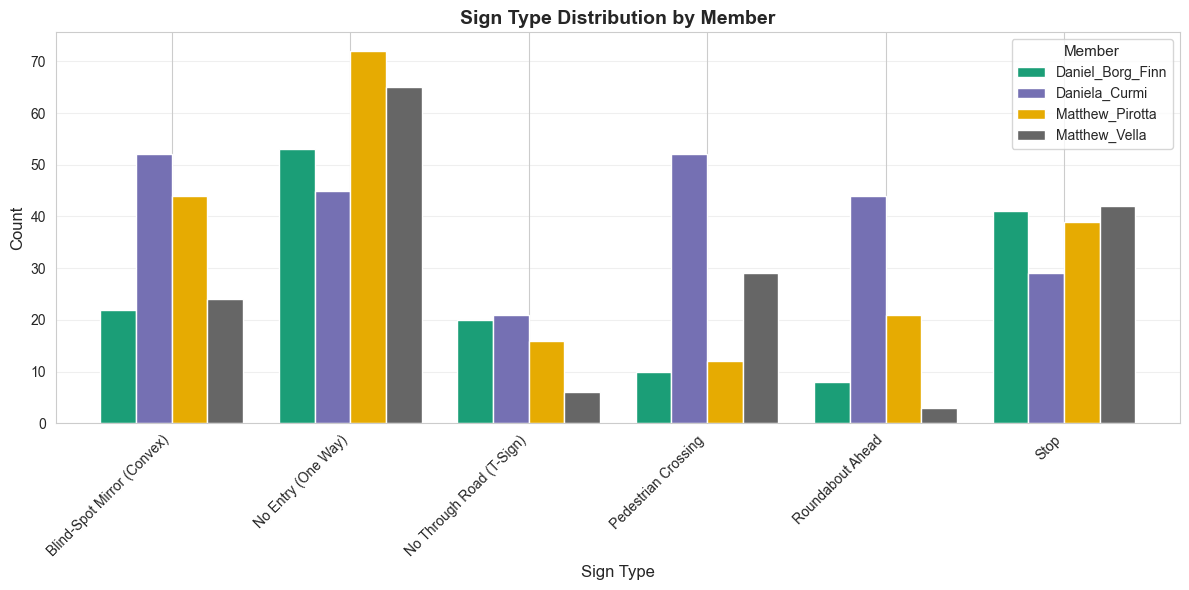

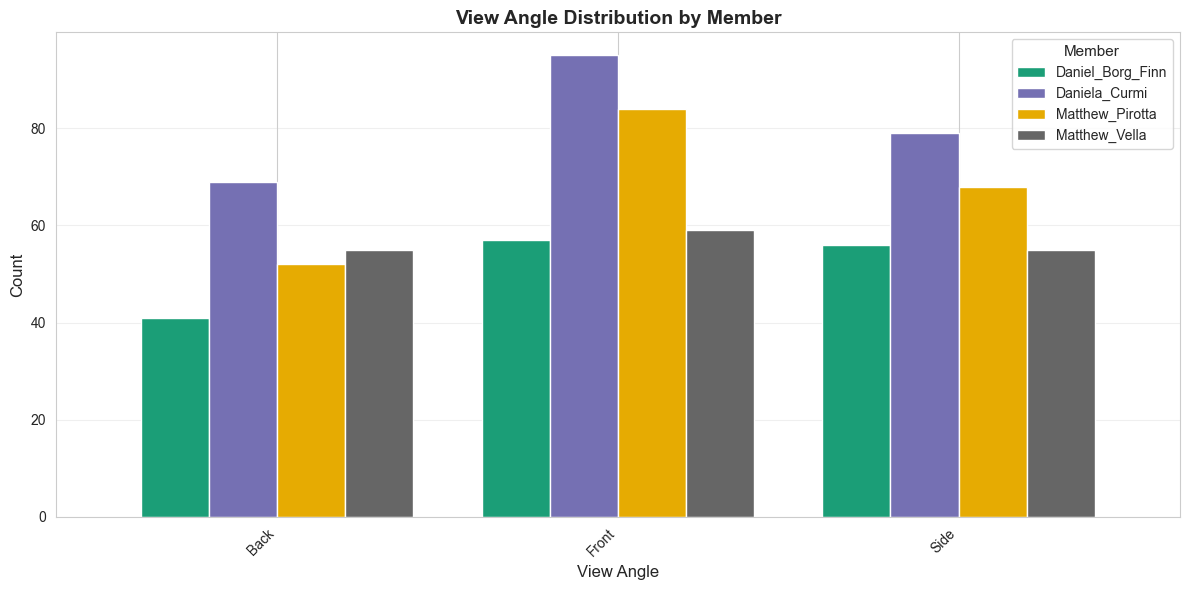

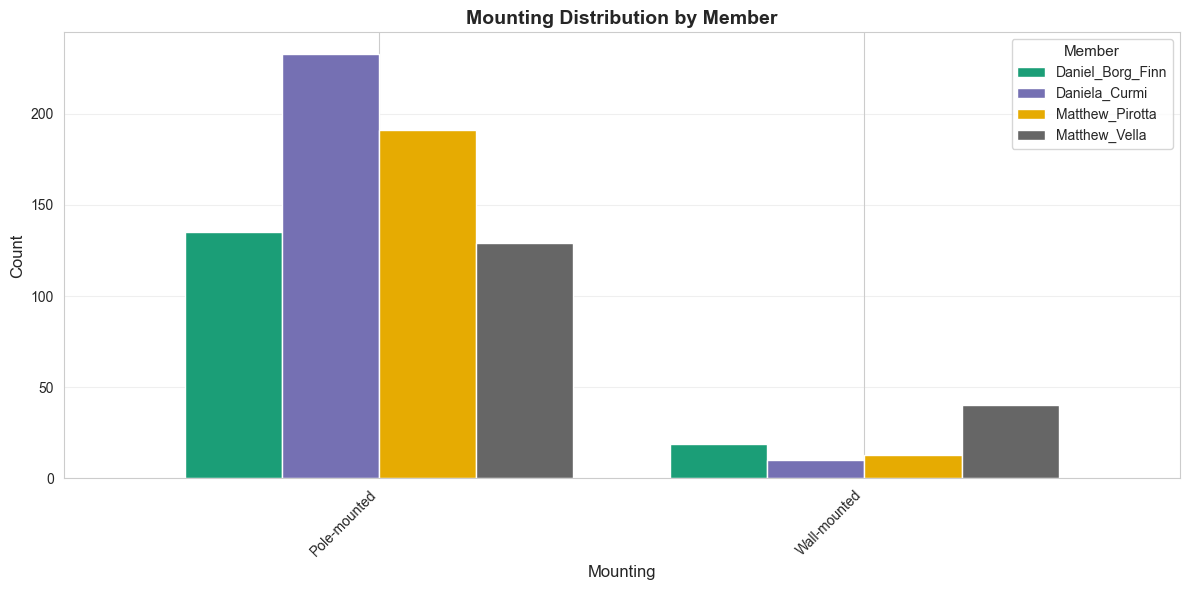

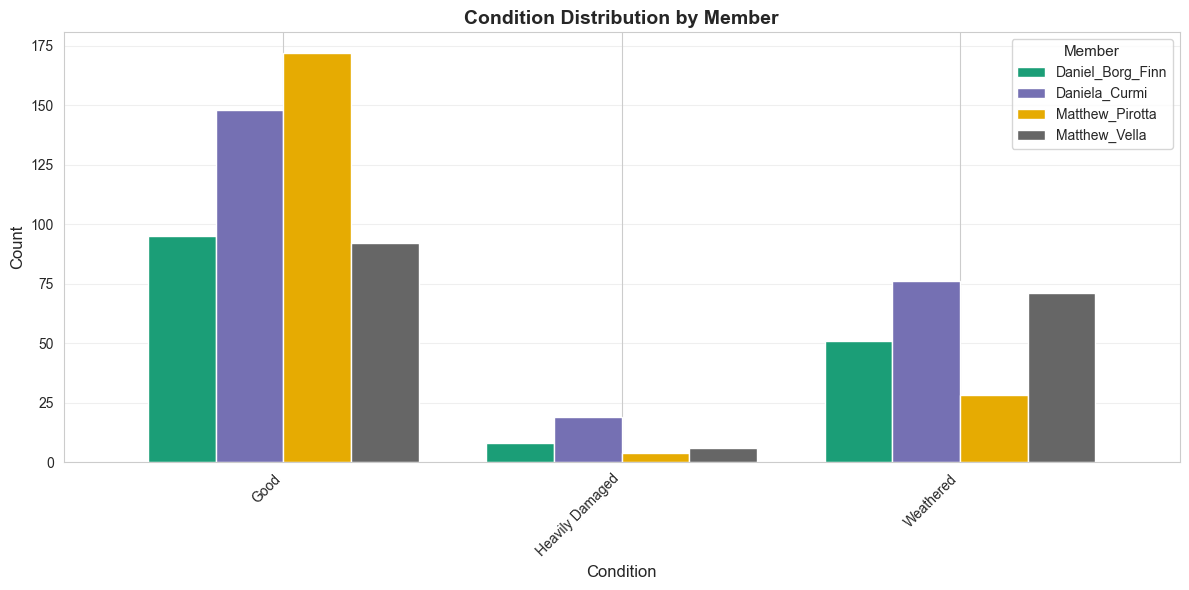

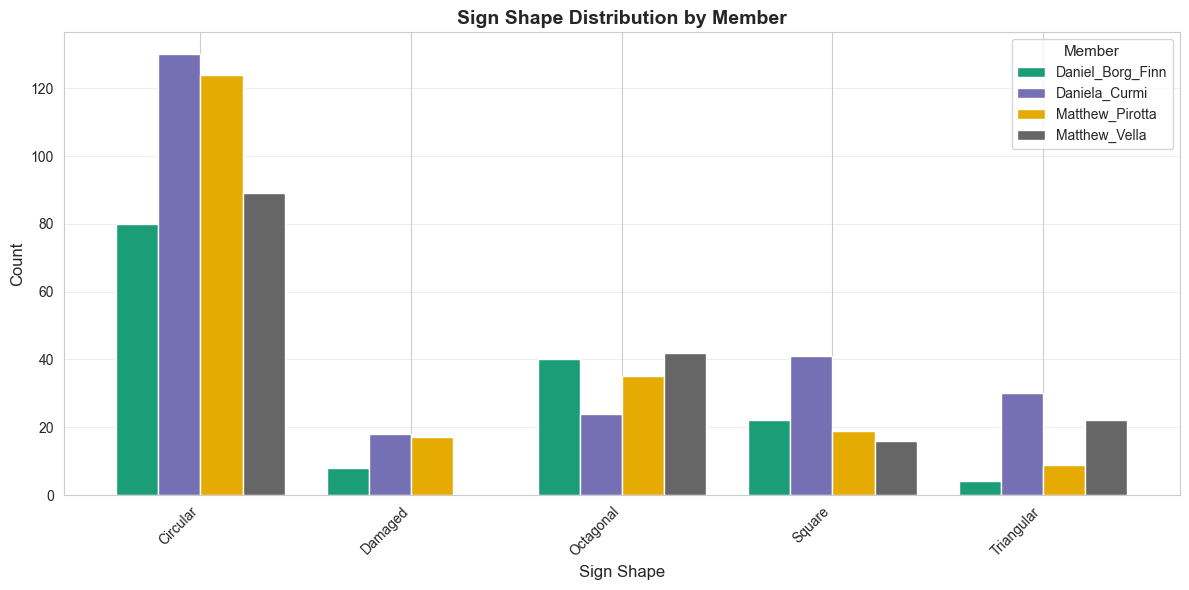

In [16]:
# Separate plots for each attribute showing member contributions side-by-side
attributes = ['sign_type', 'view_angle', 'mounting', 'condition', 'sign_shape']

for attr in attributes:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create cross-tabulation
    ct = pd.crosstab(df[attr], df['member'])
    
    # Plot side-by-side bars
    ct.plot(kind='bar', ax=ax, colormap='Dark2', width=0.8)
    
    ax.set_title(f'{attr.replace("_", " ").title()} Distribution by Member', 
                 fontweight='bold', fontsize=14)
    ax.set_xlabel(attr.replace("_", " ").title(), fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(title='Member', fontsize=10, title_fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

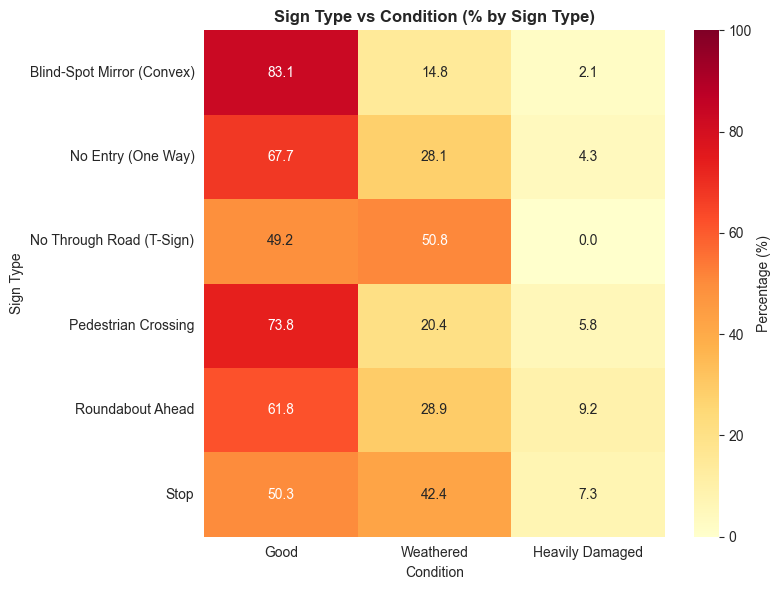

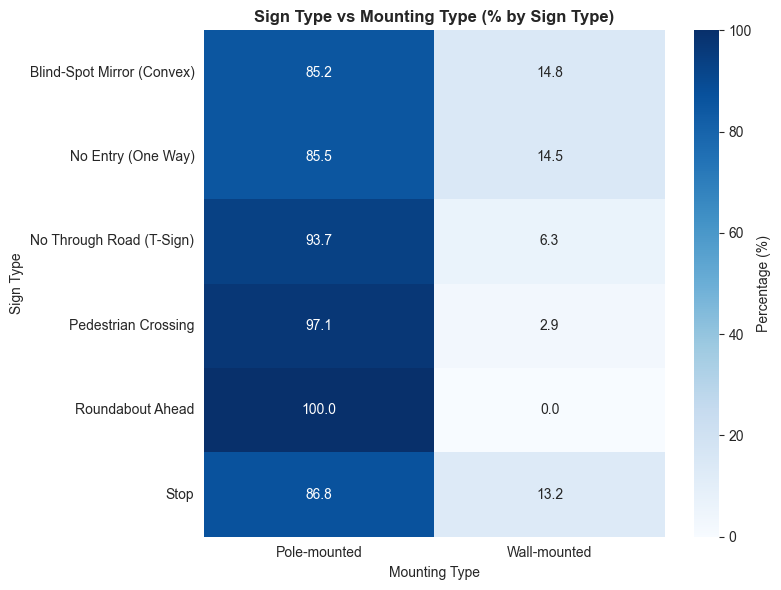

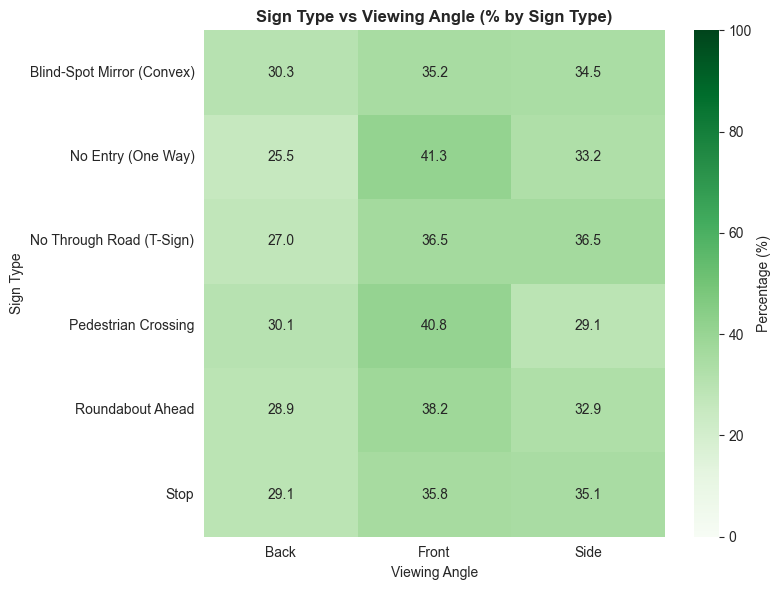

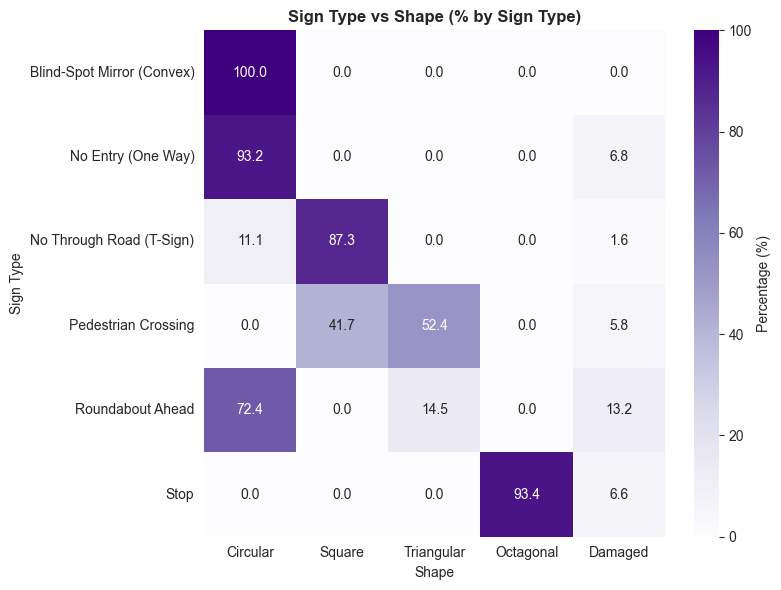

In [17]:
# 1. Sign Type vs Condition (ordered columns, percentages)
ct1 = pd.crosstab(df['sign_type'], df['condition'])
ct1 = ct1[['Good', 'Weathered', 'Heavily Damaged']]
ct1_pct = ct1.div(ct1.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    ct1_pct, annot=True, fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Percentage (%)'},
    vmin=0, vmax=100
)
plt.title('Sign Type vs Condition (% by Sign Type)', fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Sign Type')
plt.tight_layout()
plt.show()


# 2. Sign Type vs Mounting
ct2 = pd.crosstab(df['sign_type'], df['mounting'])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    ct2_pct, annot=True, fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Percentage (%)'},
    vmin=0, vmax=100
)
plt.title('Sign Type vs Mounting Type (% by Sign Type)', fontweight='bold')
plt.xlabel('Mounting Type')
plt.ylabel('Sign Type')
plt.tight_layout()
plt.show()


# 3. Sign Type vs Viewing Angle
ct3 = pd.crosstab(df['sign_type'], df['view_angle'])
ct3_pct = ct3.div(ct3.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    ct3_pct, annot=True, fmt='.1f',
    cmap='Greens',
    cbar_kws={'label': 'Percentage (%)'},
    vmin=0, vmax=100
)
plt.title('Sign Type vs Viewing Angle (% by Sign Type)', fontweight='bold')
plt.xlabel('Viewing Angle')
plt.ylabel('Sign Type')
plt.tight_layout()
plt.show()


# 4. Sign Type vs Shape (ordered columns)
ct4 = pd.crosstab(df['sign_type'], df['sign_shape'])
shape_order = ['Circular', 'Square', 'Triangular', 'Octagonal', 'Damaged']
ct4 = ct4.reindex(columns=shape_order, fill_value=0)
ct4_pct = ct4.div(ct4.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    ct4_pct, annot=True, fmt='.1f',
    cmap='Purples',
    cbar_kws={'label': 'Percentage (%)'},
    vmin=0, vmax=100
)
plt.title('Sign Type vs Shape (% by Sign Type)', fontweight='bold')
plt.xlabel('Shape')
plt.ylabel('Sign Type')
plt.tight_layout()
plt.show()
